# QSVT Algorithm Workflows

This notebook uses the high-level workflow functions in `qsvt.algorithms`.
Each workflow returns coefficients, scaled operators, polynomial results, and
classical reference diagnostics in one structured result object.

The examples stay small so the full notebook can run as a release smoke test.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from qsvt.algorithms import (
    ground_state_filtering_workflow,
    hamiltonian_simulation_workflow,
    linear_system_workflow,
    resolvent_workflow,
    spectral_density_workflow,
    thermal_gibbs_workflow,
)
from qsvt.hamiltonians import tight_binding_chain

np.set_printoptions(precision=4, suppress=True)

## Shared Toy Hamiltonian

A four-site tight-binding chain gives a compact spectrum but still supports
filtering, real-time evolution, resolvents, spectral density, and thermal
weights.

In [2]:
H = tight_binding_chain(
    4,
    hopping=0.8,
    onsite=[-0.2, 0.1, 0.35, 0.7],
)
state = np.array([1.0, 0.25, -0.1, 0.4], dtype=float)
state = state / np.linalg.norm(state)
source = np.array([1.0, 0.0, 0.0, 0.0], dtype=float)

evals = np.linalg.eigvalsh(H)
print("Eigenvalues:", evals)

Eigenvalues: [-1.1405 -0.258   0.7399  1.6086]


## Linear System Workflow

The linear-system workflow rescales a positive-definite matrix, designs a
positive inverse polynomial, and compares the polynomial solution with the exact
classical solve.

In [3]:
A = np.array(
    [
        [2.6, 0.25, 0.0, 0.0],
        [0.25, 2.2, 0.2, 0.0],
        [0.0, 0.2, 1.8, 0.15],
        [0.0, 0.0, 0.15, 1.5],
    ],
    dtype=float,
)
rhs = np.array([1.0, -0.5, 0.25, 0.75], dtype=float)
linear = linear_system_workflow(
    A,
    rhs,
    degree=7,
    num_points=301,
    bounded_num_points=601,
    attempt_synthesis=False,
    apply_qsvt=False,
)
print("Polynomial residual:", linear.polynomial_residual_norm)
print("Relative error:", linear.polynomial_relative_error)

Polynomial residual: 0.06293241692724773
Relative error: 0.04364138768069171


## Physics Workflows

The remaining workflows share the same Hamiltonian and state. Each exposes a
single diagnostic that can be tracked across parameter choices.

In [4]:
ground = ground_state_filtering_workflow(
    H,
    state,
    degree=8,
    width=0.35,
    num_points=301,
)
real_time = hamiltonian_simulation_workflow(
    H,
    state,
    time=0.8,
    degree=8,
    num_points=301,
)
green = resolvent_workflow(
    H,
    omega=0.1,
    eta=0.35,
    degree=8,
    source=source,
    num_points=301,
)
centers = np.linspace(evals[0], evals[-1], 25)
density = spectral_density_workflow(
    H,
    centers,
    width=0.35,
    degree=8,
    state=state,
    num_points=301,
)
thermal = thermal_gibbs_workflow(
    H,
    beta=0.9,
    degree=8,
    state=state,
    num_points=301,
)

summary = {
    "Ground state overlap [probability]": ground.ground_state_overlap,
    "Ground filter state error": ground.reference_state_error,
    "Hamiltonian state error": real_time.state_relative_error,
    "Resolvent response error": green.response_relative_error,
    "Spectral density error": density.trace_density_error,
    "Thermal density error": thermal.density_matrix_relative_error,
}
for key, value in summary.items():
    print(f"{key}: {value:.3e}")

Ground state overlap [probability]: 9.855e-01
Ground filter state error: 1.252e-03
Hamiltonian state error: 3.953e-08
Resolvent response error: 1.695e-01
Spectral density error: 4.670e-02
Thermal density error: 6.412e-08


## Visual Diagnostic

Plotting the spectral-density workflow makes the reference comparison visible
without inspecting the full report payload.

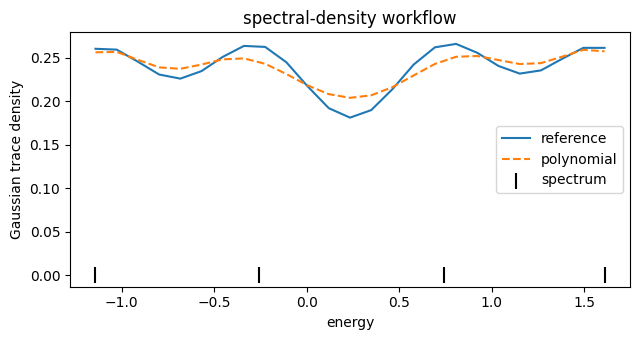

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(density.centers, density.reference_trace_density, label="reference")
ax.plot(density.centers, density.polynomial_trace_density, "--", label="polynomial")
ax.scatter(
    evals, np.zeros_like(evals), marker="|", s=120, color="black", label="spectrum"
)
ax.set_xlabel("energy")
ax.set_ylabel("Gaussian trace density")
ax.set_title("spectral-density workflow")
ax.legend(loc="best")
fig.tight_layout()

## Report Payloads

Every workflow result has an `as_report()` method. These reports can be passed
to `qsvt.reports.report_to_jsonable`, saved as JSON, or used as release
artifacts.

In [6]:
report = thermal.as_report()
print(report["mode"])
print("report keys [count/list]:", sorted(report)[:8], "...")
assert all(np.isfinite(value) for value in summary.values() if value is not None)

thermal-gibbs-workflow
report keys [count/list]: ['beta', 'coeffs', 'degree', 'density_matrix_relative_error', 'mode', 'operator_relative_error', 'polynomial_boltzmann_operator', 'polynomial_gibbs_state'] ...
